In [1]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

print(f"Loaded df of size {df.shape}")


Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (33537, 4)


In [2]:
import pandas as pd


def count_frequencies(df: pd.DataFrame) -> dict:
    return {name: dict(group['nr_arfcn'].value_counts()) for name, group in df.groupby('operator_id')}


df['counts'] = df['measurements_matrix'].apply(count_frequencies)

agg = {}
# Iterate through each row's counts
for _, row in df.iterrows():
    counts_dict = row['counts']

    # For each operator in the counts dictionary
    for operator_id, nr_arfcn_counts in counts_dict.items():
        # Initialize the operator in the agg dict if it doesn't exist
        if operator_id not in agg:
            agg[operator_id] = {}

        # For each nr_arfcn and its count
        for nr_arfcn, count in nr_arfcn_counts.items():
            # Convert numpy.int64 to regular int if needed
            count_value = int(count) if hasattr(count, 'item') else count

            # Add to existing count or initialize
            if nr_arfcn in agg[operator_id]:
                agg[operator_id][nr_arfcn] += count_value
            else:
                agg[operator_id][nr_arfcn] = count_value

In [32]:
from scripts.utils import get_config

aggregated_df = pd.DataFrame(agg)

aggregated_df

band_map = get_config("band_map.json")

color_map = get_config("color_map.json", "operatorId")

color_map = {int(k): v for k, v in color_map.items()}

color_map

{1: '#004A98', 10: '#E60001', 50: '#22c55e', 88: '#a855f7'}

In [67]:
cols = ['operator_id', 'band', 'count']
data = []
for nr, row in aggregated_df.iterrows():
    for op in [1, 10, 50, 88]:
        if op in row and not pd.isna(row[op]):
            band = f'n{band_map[str(op)][str(int(nr))]}'
            data.append([op, band, int(row[op])])

band_df = pd.DataFrame(data, columns=cols)

sums = band_df.groupby(['operator_id', 'band'])['count'].sum().reset_index()

cats = [f'n{sor}' for sor in sorted([int(s[1:]) for s in sums['band'].unique().tolist()])]

sums['band'] = pd.Categorical(sums['band'], categories=cats, ordered=True)

sums.sort_values('band', inplace=True)

sums.groupby(['operator_id', 'band'])['count'].sum()

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_13700/877345867.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sums.groupby(['operator_id', 'band'])['count'].sum()


operator_id  band
1            n1            0
             n3            0
             n7            0
             n28           0
             n66           0
             n78      216244
10           n1       103093
             n3            0
             n7            0
             n28       17850
             n66      127375
             n78     2044310
50           n1            0
             n3            0
             n7            0
             n28      312409
             n66           0
             n78      760780
88           n1            0
             n3       256008
             n7         4754
             n28           0
             n66           0
             n78     1438059
Name: count, dtype: int64

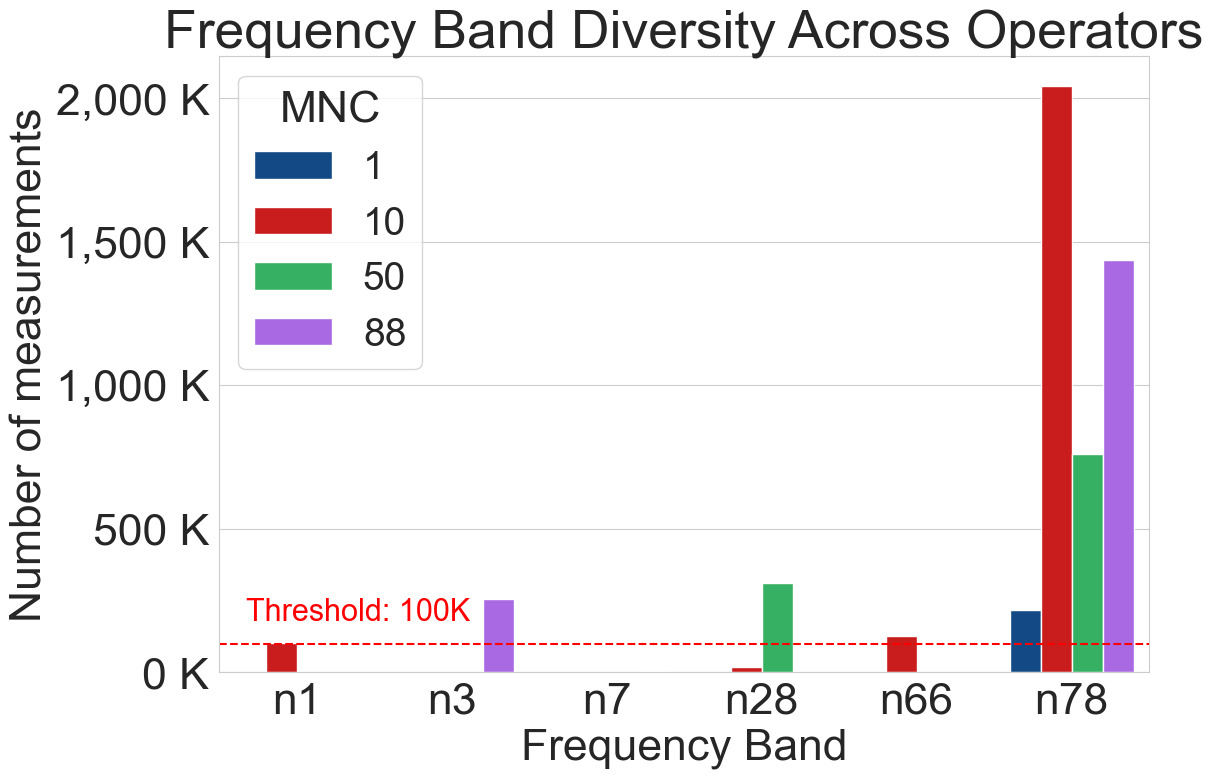

In [101]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sns


# Custom formatter function for y-axis
def thousands_formatter(x, pos):
    if x >= 10 ** 6:
        f = str(x / 10 ** 6).replace('.', ',')
        return f'{f}00 K'
    return f'{int(x / 1000)} K'


# Update plot font size
plt.rcParams.update({"font.size": 32})

plt.figure(figsize=(12, 8))

# Create the bar plot
ax = sns.barplot(data=sums, x='band', hue='operator_id', y='count', palette=color_map)

ax.axhline(y=100000, color='red', linestyle='--')
ax.text(x=0.4, y=100000 + 80000, s='Threshold: 100K', color='red', fontsize=22, ha='center')

# Apply the custom formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.legend(loc='upper left', title='MNC', fontsize='28')
plt.ylabel('Number of measurements')
plt.xlabel('Frequency Band')
plt.title('Frequency Band Diversity Across Operators')

plt.show()

In [103]:
sums.groupby(['operator_id', 'band'])['count'].sum()

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_13700/3939558840.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sums.groupby(['operator_id', 'band'])['count'].sum()


operator_id  band
1            n1            0
             n3            0
             n7            0
             n28           0
             n66           0
             n78      216244
10           n1       103093
             n3            0
             n7            0
             n28       17850
             n66      127375
             n78     2044310
50           n1            0
             n3            0
             n7            0
             n28      312409
             n66           0
             n78      760780
88           n1            0
             n3       256008
             n7         4754
             n28           0
             n66           0
             n78     1438059
Name: count, dtype: int64